In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/sentiment_posts.csv")

In [3]:
df.shape


(2091, 21)

In [4]:
df.head()


,Unnamed: 0.1,Unnamed: 0,id,title,body,score,upvote_ratio,num_comments,flair,author,...,permalink,created_utc,category,is_self_post,domain,top_comments,full_text,clean_text,sentiment,confidence
0,0,0,1rlblhn,"President Bought Netflix Debt in January 2026,...",NaN,8871,0.97,568,Business,ControlCAD,...,https://reddit.com/r/technology/comments/1rlbl...,2026-03-05 13:19:32,hot,False,hollywoodreporter.com,"1. Breaks the law.\n\n2. Gets criticized, back...","President Bought Netflix Debt in January 2026,...",president bought netflix debt in january 2026 ...,negative,0.5265
1,1,1,1rl6lay,US air defenses may not be able to intercept m...,NaN,5598,0.95,814,Business,esporx,...,https://reddit.com/r/technology/comments/1rl6l...,2026-03-05 08:52:32,hot,False,cnn.com,They've only been watching the war in Ukraine ...,US air defenses may not be able to intercept m...,us air defenses may not be able to intercept m...,negative,0.6667
2,2,2,1rlhffx,GOP state lawmakers urge White House to halt e...,NaN,732,0.97,52,Artificial Intelligence,FinnFarrow,...,https://reddit.com/r/technology/comments/1rlhf...,2026-03-05 18:49:23,hot,False,thehill.com,The White House can't do anything about it. Co...,GOP state lawmakers urge White House to halt e...,gop state lawmakers urge white house to halt e...,negative,0.6376
3,3,3,1rkv7az,Brendan Carr Can’t Explain Why ‘Equal Time’ Ru...,NaN,23944,0.96,401,Politics,StraightedgexLiberal,...,https://reddit.com/r/technology/comments/1rkv7...,2026-03-05 01:06:37,hot,False,techdirt.com,> In a press conference after the FCC’s Februa...,Brendan Carr Can’t Explain Why ‘Equal Time’ Ru...,brendan carr can t explain why equal time rule...,neutral,0.5808
4,4,4,1rlejk6,"I was at a QuitGPT protest, and the discontent...",NaN,790,0.96,22,Artificial Intelligence,FinnFarrow,...,https://reddit.com/r/technology/comments/1rlej...,2026-03-05 16:20:59,hot,False,businessinsider.com,Any wonder? AI just rolls out from beneath a r...,"I was at a QuitGPT protest, and the discontent...",i was at a quitgpt protest and the discontent ...,negative,0.8899


In [5]:
df.describe(include="all")

,Unnamed: 0.1,Unnamed: 0,id,title,body,score,upvote_ratio,num_comments,flair,author,...,permalink,created_utc,category,is_self_post,domain,top_comments,full_text,clean_text,sentiment,confidence
count,2091.000000,2091.000000,2091,2091,12,2091.000000,2091.000000,2091.000000,2091,2091,...,2091,2091,2091,2091,2091,1110,2091,2091,2091,2091.000000
unique,NaN,NaN,2091,2081,12,NaN,NaN,NaN,42,657,...,2091,2091,5,2,466,1110,2090,2090,3,NaN
top,NaN,NaN,in1fwi,Human brain cells on a chip learned to play Do...,All it takes is one call. It's our internet. \...,NaN,NaN,NaN,Artificial Intelligence,Logical_Welder3467,...,https://reddit.com/r/technology/comments/in1fw...,2020-09-05 19:21:33,hot,False,techcrunch.com,"So, let me see, he has tweeted, and this is a ...",I know you’re tired of hearing about net neutr...,i know you re tired of hearing about net neutr...,negative,NaN
freq,NaN,NaN,1,2,1,NaN,NaN,NaN,400,135,...,1,1,999,2079,96,1,2,2,1311,NaN
mean,1045.000000,1045.000000,NaN,NaN,NaN,23182.190818,0.867174,1180.452415,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.724237
std,603.764027,603.764027,NaN,NaN,NaN,28622.741188,0.158333,1734.915270,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.132295
min,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.060000,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.368100
25%,522.500000,522.500000,NaN,NaN,NaN,157.000000,0.850000,27.500000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.616950
50%,1045.000000,1045.000000,NaN,NaN,NaN,4604.000000,0.920000,344.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.743100
75%,1567.500000,1567.500000,NaN,NaN,NaN,46179.000000,0.960000,1788.500000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.837700


<h1>Top word per sentiment class</h1>
<h3>TF-IDF ANALYSIS</h3>

In [6]:
tfidf_results={}

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [8]:
for sentiment in ["positive", "negative", "neutral"]:
    subset = df[df["sentiment"] == sentiment]["clean_text"].dropna()
    tfidf = TfidfVectorizer(max_features = 30, stop_words = "english", ngram_range=(1, 2))
    tfidf.fit_transform(subset)
    words = tfidf.get_feature_names_out().tolist()
    tfidf_results[sentiment] = words
    print(",".join(words))
    print("-"*50)

000,10,ai,apple,battery,company,day,don,free,going,good,google,great,just,like,make,motorola,new,people,pretty,really,right,tech,thing,time,use,ve,want,year,years
--------------------------------------------------
ai,companies,company,data,don,going,good,government,just,know,like,make,media,need,new,people,really,reddit,said,says,social,tech,time,trump,use,using,want,way,work,years
--------------------------------------------------


ai,anthropic,app,billion,companies,company,data,don,fcc,government,ice,just,like,make,media,net,net neutrality,neutrality,new,openai,pentagon,people,said,says,tech,time,trump,use,work,years
--------------------------------------------------


<h1>Visualize TF-IDF per sentiment</h1>


Text(0.5, 1.02, 'Most Significant Words per Sentiment Class')

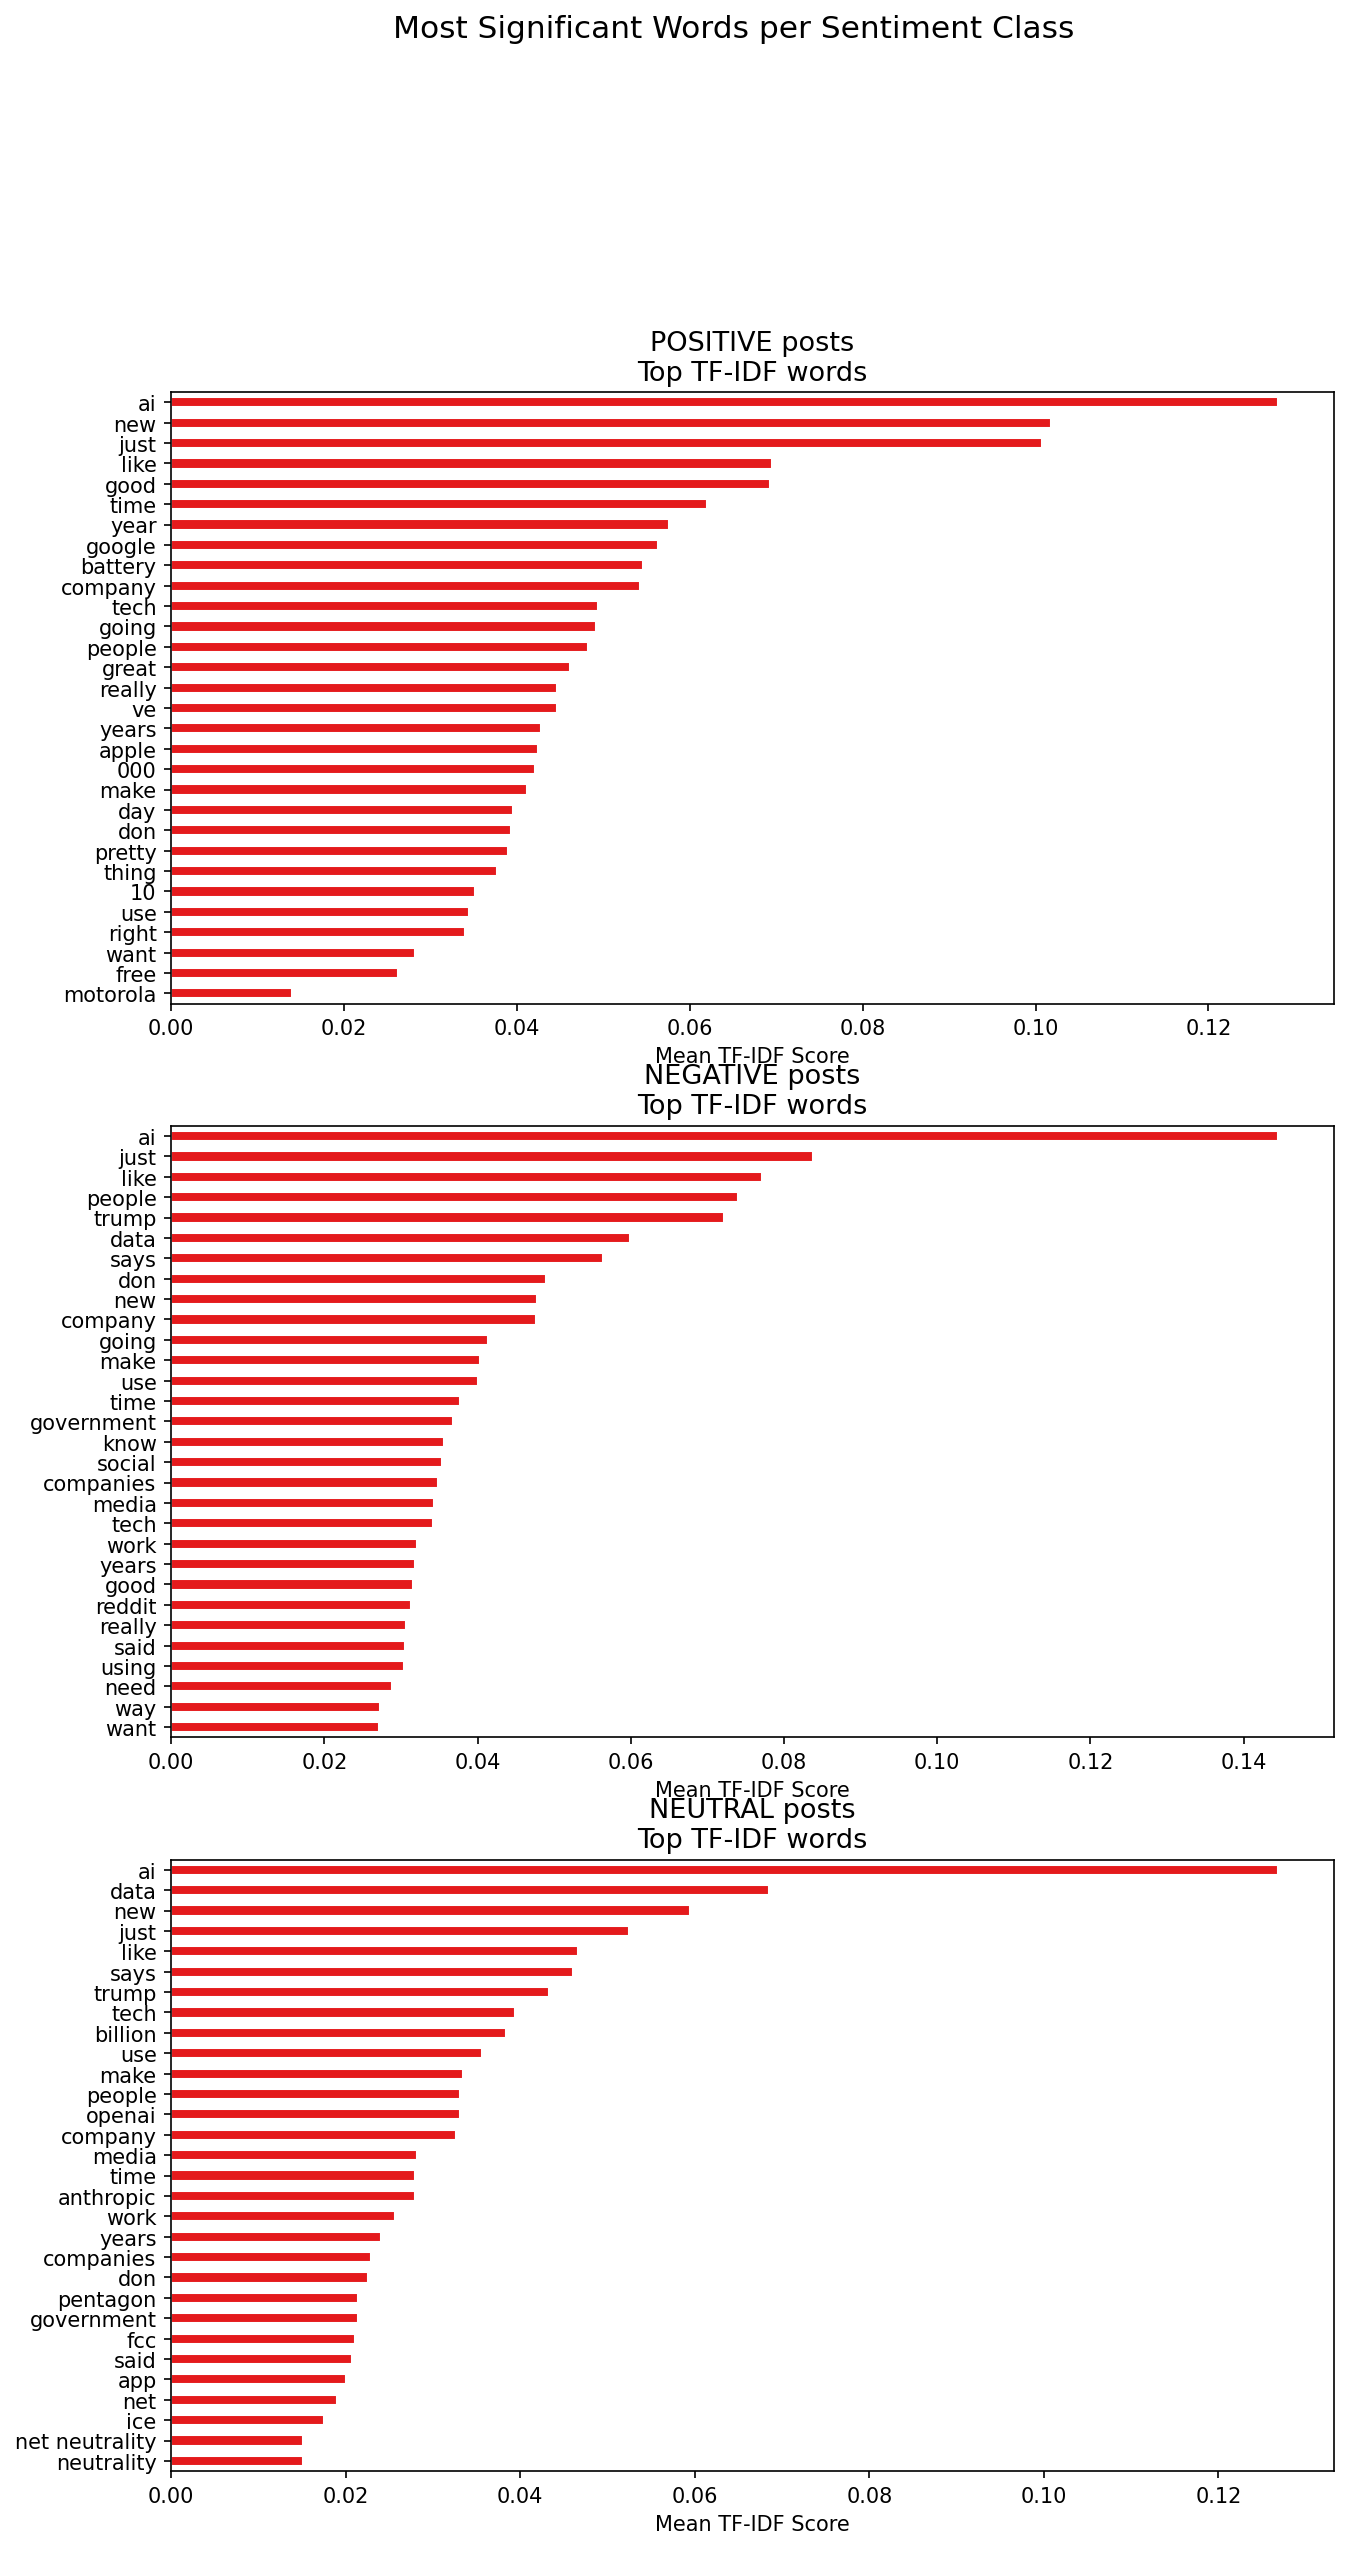

In [9]:
fig, axes = plt.subplots(3,1, figsize=(10, 18),dpi=150)
for ax, sentiment in zip(axes, ["positive", "negative", "neutral"]):
    subset = df[df["sentiment"] == sentiment]["clean_text"].dropna()
    tfidf = TfidfVectorizer(max_features = 30, stop_words = "english", ngram_range=(1, 2))
    matrix = tfidf.fit_transform(subset)
    scores = matrix.mean(axis=0).A1 #converts a 2d error to 1d array
    words = tfidf.get_feature_names_out()
    word_scores = pd.Series(scores, index=words).sort_values(ascending=True)
    word_scores.plot(kind = "barh", ax = ax, edgecolor = "white",colormap="Set1")
    ax.set_title(f"{sentiment.upper()} posts\nTop TF-IDF words", fontsize=13)
    ax.set_xlabel("Mean TF-IDF Score")

plt.suptitle("Most Significant Words per Sentiment Class", fontsize=15, y=1.02)

<h1>Building Tf-IDF matrix for LDA</h1>

In [10]:
tfidf_full= TfidfVectorizer(max_features = 1000, stop_words = "english", ngram_range=(1, 2),min_df=5,max_df=.95)
tf_idf_matrix=tfidf_full.fit_transform(df["clean_text"].fillna(""))
feature_names=tfidf_full.get_feature_names_out()
tf_idf_matrix.shape

(2091, 1000)

<h3>Posts is 2091 and Features is 1000</h3>
<h1>Fitting LDA</h1>

In [11]:
from sklearn.decomposition import LatentDirichletAllocation

In [12]:
lda=LatentDirichletAllocation(n_components=15,random_state=1000,max_iter=30)


In [13]:
lda.fit(tf_idf_matrix)
for i , topic in enumerate(lda.components_):
    top_words=[feature_names[j] for j in topic.argsort()[-20:]][::-1]
    print(f" Top words: {','.join(top_words)}")

 Top words: netflix,paramount,stock,warner,bros,warner bros,nvidia,billion,market,investors,american,death,shares,investment,tesla,corrupt,fees,review,company,deal
 Top words: ai,like,just,people,don,use,trump,new,company,work,good,data,going,time,really,years,companies,know,right,need
 Top words: social,social media,media,twitter,musk,meta,elon,elon musk,accounts,bots,reddit,dead,facebook,platforms,children,users,posts,11,ceo,anti
 Top words: google,russia,china,drone,12,iphone,amazon,spotify,app,weapons,ukraine,web,iran,apps,calls,ice,subscription,members,gemini,sold
 Top words: texas,canada,encryption,evs,500,cars,global,uk,section,ford,eu,mobile,firm,million,washington,attack,dumb,update,university,hell
 Top words: sales,boom,ev,pay,latest,workers,york,new york,new,sinclair,nvidia,revenue,study,know,billion,amazon,share,reports,intelligence,news
 Top words: facebook,white house,white,electric,house,study,wing,propaganda,slop,ai slop,youtube,right wing,right,russian,return,live,fail

<h1>Manually Labelling Topics</h1>

In [14]:
TOPIC_LABELS = {
    1: "Entertainment & Tech Software News",
    2: "Big Tech Updates & Cybersecurity",
    3: "Cyber Breaches & Government Oversight",
    4: "Social Media Regulation & Privacy",
    5: "General AI Discourse",
    6: "Big Tech Leadership & Employment",
    7: "Net Neutrality & FCC Regulations",
    8: "Sam Altman & OpenAI Leadership",
    9: "Age Verification & Hardware Privacy",
    10: "Consumer Tech & Global News",
    11: "AI Companies & Government Investigations",
    12: "AI Infrastructure & Data Centers",
    13: "Elon Musk & Social Media Platforms",
    14: "Tech Billionaires & Surveillance Tech",
    15: "Military AI & Open Source"
}

for k, v in TOPIC_LABELS.items():
    print(f"  Topic {k}: {v}")

  Topic 1: Entertainment & Tech Software News
  Topic 2: Big Tech Updates & Cybersecurity
  Topic 3: Cyber Breaches & Government Oversight
  Topic 4: Social Media Regulation & Privacy
  Topic 5: General AI Discourse
  Topic 6: Big Tech Leadership & Employment
  Topic 7: Net Neutrality & FCC Regulations
  Topic 8: Sam Altman & OpenAI Leadership
  Topic 9: Age Verification & Hardware Privacy
  Topic 10: Consumer Tech & Global News
  Topic 11: AI Companies & Government Investigations
  Topic 12: AI Infrastructure & Data Centers
  Topic 13: Elon Musk & Social Media Platforms
  Topic 14: Tech Billionaires & Surveillance Tech
  Topic 15: Military AI & Open Source


In [15]:
topic_distribution=lda.transform(tf_idf_matrix)

In [16]:
df["Dominant_topics"]=topic_distribution.argmax(axis=1)+1
df["topic_confidance"]=topic_distribution.max(axis=1).round(4)
df["Topic_labels"]=df["Dominant_topics"].map(TOPIC_LABELS)


In [17]:
df["Dominant_topics"].value_counts().sort_index()

Dominant_topics
1       60
2     1068
3       87
4       71
5       44
6       33
7       56
8       85
9       87
10      76
11      73
12     171
13      54
14      84
15      42
Name: count, dtype: int64

<h1>Visualization</h1>

Text(0.5, 0, 'Number of Posts')

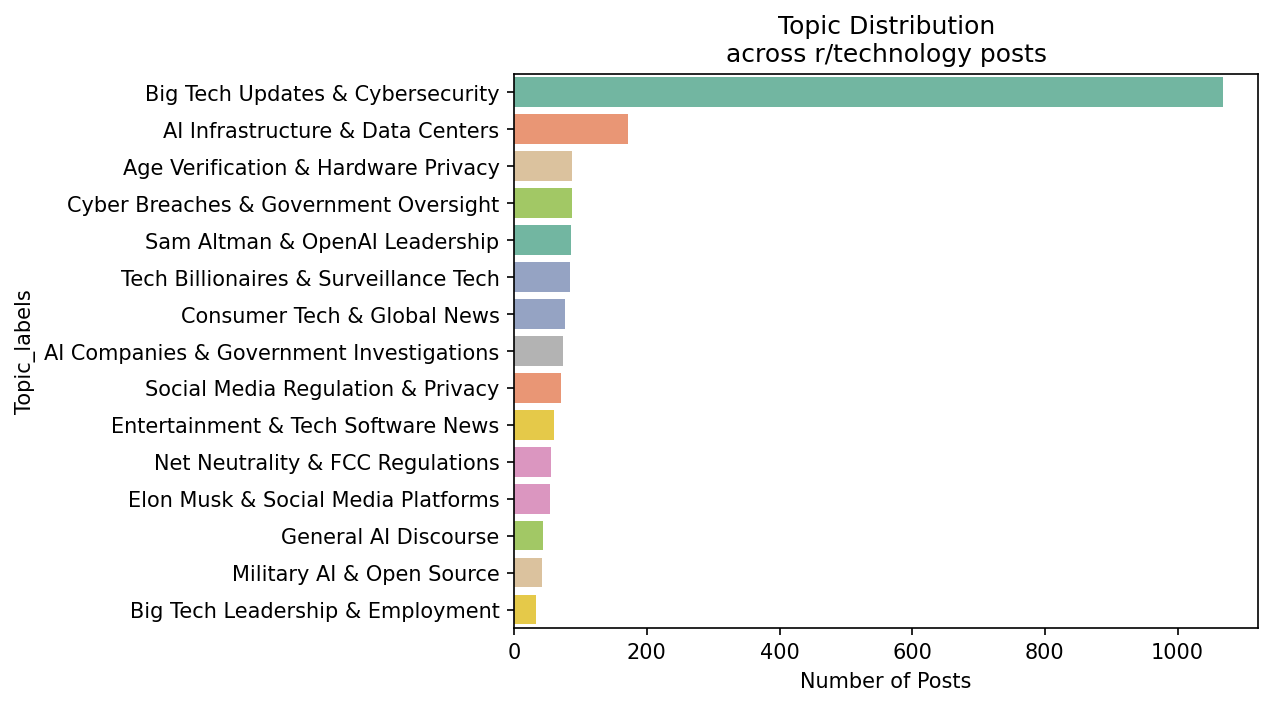

In [18]:
plt.figure(dpi=150)
sns.countplot(data=df, y="Topic_labels",hue="Topic_labels",palette="Set2",order=df["Topic_labels"].value_counts().index)
plt.title("Topic Distribution\nacross r/technology posts")
plt.xlabel("Number of Posts")

Text(0.5, 0, 'Percentage (%)')

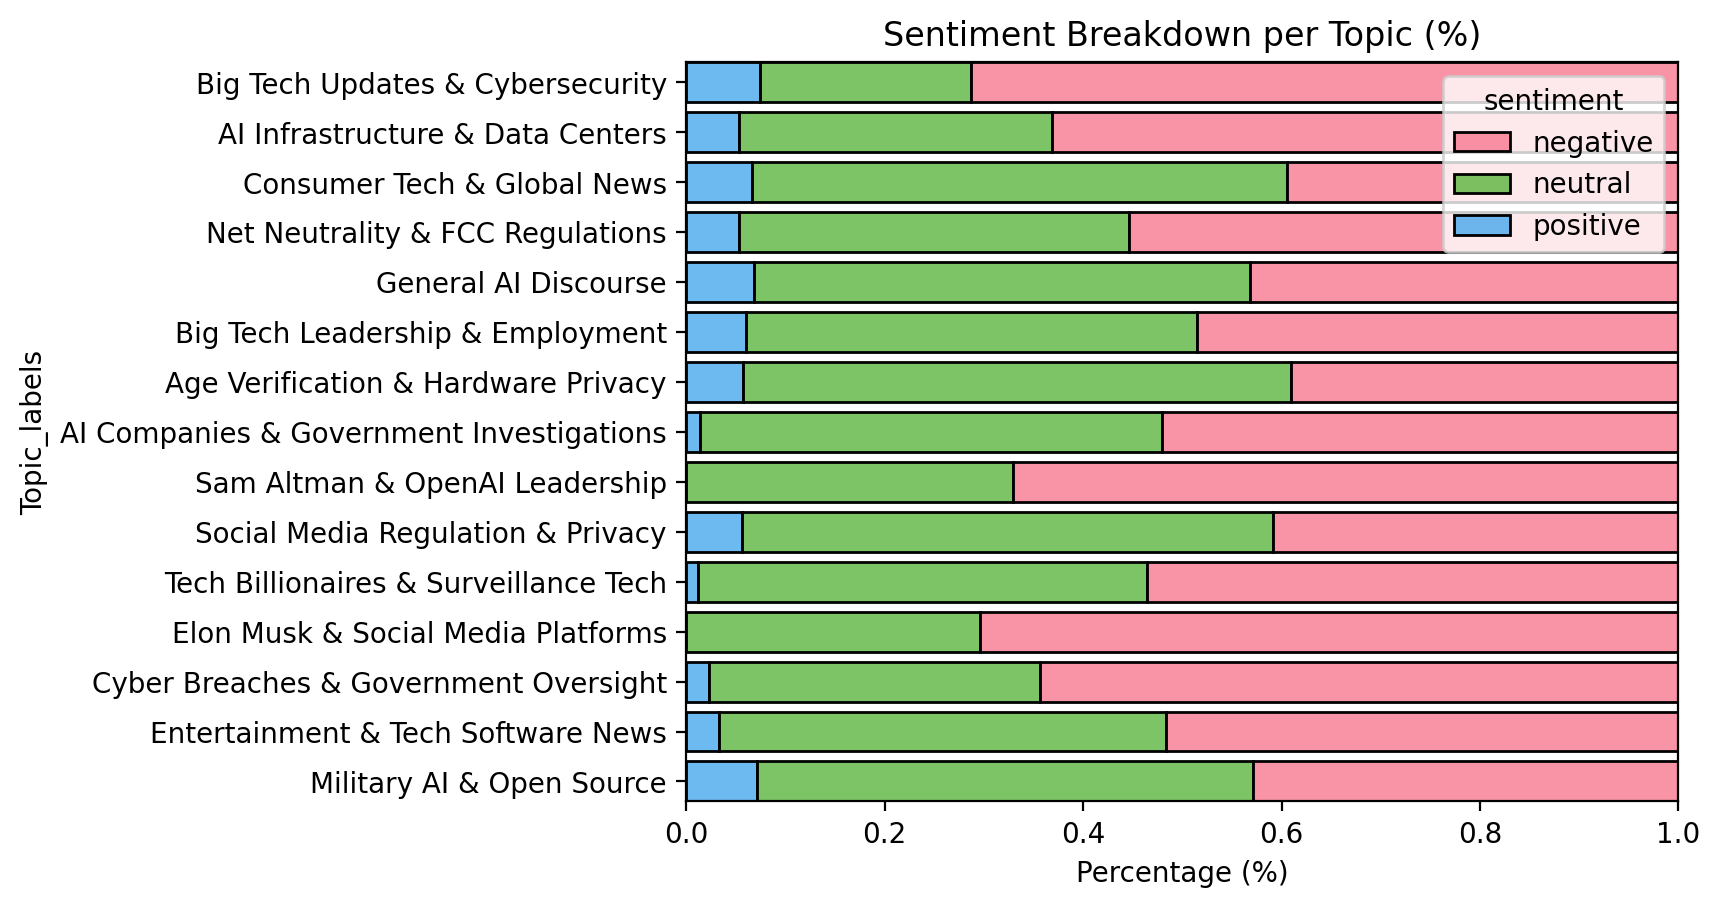

In [19]:
plt.figure(dpi=200)
sns.histplot(data=df,  y="Topic_labels", hue="sentiment", multiple="fill", shrink=0.8, 
             palette="husl" )
plt.title("Sentiment Breakdown per Topic (%)")
plt.xlabel("Percentage (%)")

Text(0.5, 1.0, 'Topic vs Sentiment Heatmap\n(post counts)')

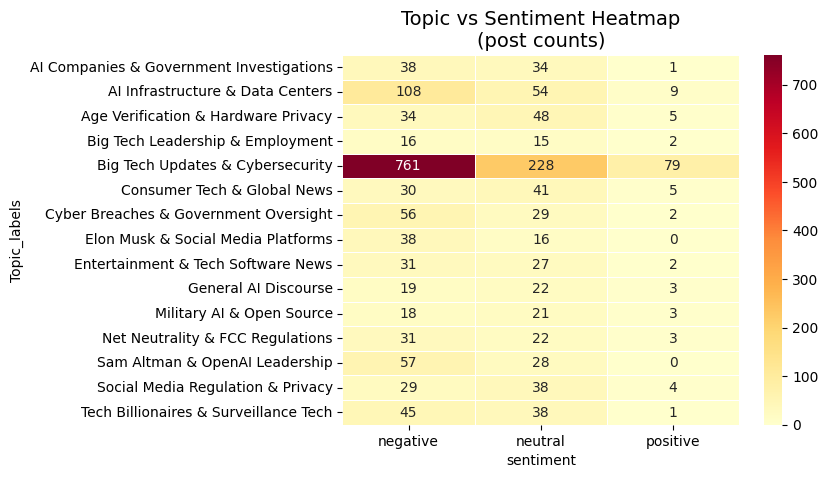

In [20]:
sns.heatmap(pd.crosstab(df["Topic_labels"], df["sentiment"]), annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)

plt.title("Topic vs Sentiment Heatmap\n(post counts)", fontsize=14)

<h1>NER - Named Entity Recognition</h1>

In [21]:
!pip install spacy


In [22]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/12.8 MB ? eta -:--:--

     ━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━ 6.8/12.8 MB 38.4 MB/s eta 0:00:01

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 50.9 MB/s  0:00:00


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [23]:
import spacy

In [24]:
nlp = spacy.load("en_core_web_sm")
def extract_entities(text):
    try:
        doc = nlp(str(text)[:1000])
        orgs = [ent.text.strip() for ent in doc.ents if ent.label_ == "ORG"]
        persons = [ent.text.strip() for ent in doc.ents if ent.label_ == "PERSON"]
        return " | ".join(orgs), " | ".join(persons)
    except:
        return "", ""

orgs_list = []
persons_list = []

for i, text in enumerate(df["clean_text"]):
    if i%300 == 0:
        print(f"Progress: {i}/{len(df)}")
    orgs, persons = extract_entities(text)
    orgs_list.append(orgs)
    persons_list.append(persons)

df["orgs"] = orgs_list
df["persons"] = persons_list

Progress: 0/2091


Progress: 300/2091


Progress: 600/2091


Progress: 900/2091


Progress: 1200/2091


Progress: 1500/2091


Progress: 1800/2091


In [25]:
(df['orgs'] != '').sum()

np.int64(706)

In [26]:
(df['persons'] != '').sum()

np.int64(627)

In [27]:
all_orgs = []
for t, row in df.iterrows():
    if isinstance(row["orgs"], str) and row["orgs"]:
        for org in row["orgs"].split(" | "):
            org = org.strip()
            if len(org) > 2:
                all_orgs.append({"org": org, "sentiment": row["sentiment"], "score" : row["score"]})
orgs_df = pd.DataFrame(all_orgs)
top_orgs = orgs_df["org"].value_counts().head(20).index.tolist()
orgs_filtered = orgs_df[orgs_df["org"].isin(top_orgs)]
org_sentiment = orgs_filtered.groupby(["org", "sentiment"]).size().unstack(fill_value=0)
org_sentiment_pct = (org_sentiment.div(org_sentiment.sum(axis = 1), axis = 0) * 100).round(1)
org_values = org_sentiment_pct.sort_values("negative", ascending=False)
org_values

sentiment,negative,neutral,positive
org,,,
abc,90.9,9.1,0.0
gop,86.7,13.3,0.0
the white house,83.3,8.3,8.3
microsoft,80.4,15.7,3.9
white house,78.9,21.1,0.0
google,70.7,19.5,9.8
ibm,70.0,30.0,0.0
amazon,66.7,25.0,8.3
meta,66.7,33.3,0.0


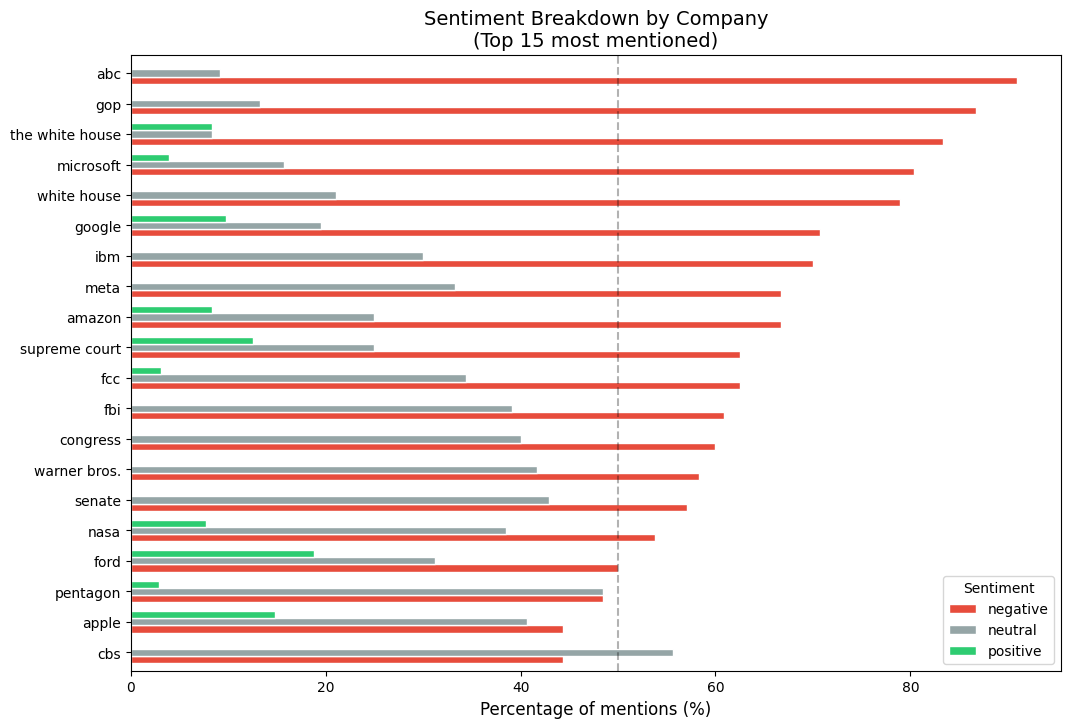

In [28]:
plot_data = org_sentiment_pct.sort_values("negative", ascending=True)

plot_data.plot(
    kind="barh",
    figsize=(12, 8),
    color=["#e74c3c", "#95a5a6", "#2ecc71"],
    edgecolor="white",
    width=0.7
)

plt.title("Sentiment Breakdown by Company\n(Top 15 most mentioned)", fontsize=14)
plt.xlabel("Percentage of mentions (%)", fontsize=12)
plt.ylabel("")
plt.legend(title="Sentiment", loc="lower right")
plt.axvline(x=50, color="black", linestyle="--", alpha=0.3)

In [29]:
df.to_csv("../data/nlp_posts.csv")